# HMS v12 — High-Consensus EEG Classification

**Key changes from v11:**
- Train/validate only on samples with ≥70% expert consensus
- n_fft=512, bandpass 0.5–20 Hz, GRU 2×256
- AMP enabled, batch_size=24
- Per-group weight decay (0 for STFT, 1e-2 for backbone/head)
- STFT LR=1e-4 (below head), MixUp α=0.5
- softmax numerically stable loss
- Single-stage training, 1-epoch warmup cosine

In [1]:
import os, math, random, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
from nnAudio.features import STFT
from sklearn.model_selection import StratifiedGroupKFold
from scipy.signal import butter, sosfiltfilt
import joblib

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128, CUDA: True
GPU: Tesla T4


# Configuration

In [ ]:
class CFG:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Classes
    num_classes = 6
    class_names = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
    name2label = {v: k for k, v in enumerate(class_names)}

    # EEG
    eeg_sample_rate = 200
    eeg_duration = 50
    eeg_samples = eeg_sample_rate * eeg_duration  # 10000
    num_bipolar_channels = 16

    # Bandpass
    bandpass_low = 0.5
    bandpass_high = 20.0
    bandpass_order = 4

    # STFT
    n_fft = 512                 # 0.39 Hz/bin → 52 bins to 20 Hz
    hop_length = 128
    zoom_duration = 10
    zoom_hop_length = 32
    freq_crop_hz = 20.0
    trainable_stft = True

    # Model
    backbone = "tf_efficientnetv2_b2"
    gru_hidden = 256
    gru_layers = 2
    dropout = 0.35

    # Training
    epochs = 20
    batch_size = 16
    use_amp = False
    max_grad_norm = 1.0
    num_workers = 4
    n_folds = 5
    run_folds = [1, 2, 3, 4] # [0]

    # Learning rates (head > STFT > backbone)
    lr_head = 3e-4
    lr_stft = 1e-4
    lr_backbone = 5e-5
    warmup_epochs = 1

    # Data filtering
    min_consensus = 0.70        # only train/validate on ≥70% agreement
    use_soft_labels = True
    label_smoothing = 0.05

    # Augmentation
    mixup_alpha = 0.5
    spec_freq_mask = 10
    spec_time_mask = 10
    spec_num_masks = 2

# Print summary
max_bin = int(CFG.freq_crop_hz / (CFG.eeg_sample_rate / CFG.n_fft)) + 1
wide_frames = (CFG.eeg_samples - CFG.n_fft) // CFG.hop_length + 1
print(f"STFT: n_fft={CFG.n_fft}, {max_bin} freq bins, {wide_frames} time frames")
print(f"Image: [3, {16 * max_bin}, {wide_frames}]")
print(f"Filter: consensus ≥ {CFG.min_consensus:.0%}")
print(f"Training: {CFG.epochs} epochs, batch={CFG.batch_size}, AMP={CFG.use_amp}")
print(f"LRs: head={CFG.lr_head}, stft={CFG.lr_stft}, backbone={CFG.lr_backbone}")

STFT: n_fft=512, 52 freq bins, 75 time frames
Image: [3, 832, 75]
Filter: consensus ≥ 70%
Training: 20 epochs, batch=16, AMP=False
LRs: head=0.0003, stft=0.0001, backbone=5e-05


In [3]:
def set_seed(seed=CFG.seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

# Paths

In [4]:
project_root = Path.cwd()
BASE_PATH = project_root.parent.parent.parent / "data" / "data"

MODELS_DIR = project_root / "models"
RESULTS_DIR = project_root / "results"
PROCESSED_DIR = BASE_PATH / "processed" / "bipolar_eegs"
for d in [MODELS_DIR, RESULTS_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data: {BASE_PATH} (exists={BASE_PATH.exists()})")
print(f"Processed EEGs: {PROCESSED_DIR}")

Data: /home/littl/data/data (exists=True)
Processed EEGs: /home/littl/data/data/processed/bipolar_eegs


# Metadata & Consensus Filter

In [5]:
# Load train data
df = pd.read_csv(BASE_PATH / "train.csv")
df["eeg_path"] = df["eeg_id"].apply(lambda x: str(BASE_PATH / "train_eegs" / f"{x}.parquet"))
df["class_name"] = df["expert_consensus"].copy()
df["class_label"] = df["expert_consensus"].map(CFG.name2label)

# Compute soft labels and consensus
vote_cols = ["seizure_vote", "lpd_vote", "gpd_vote", "lrda_vote", "grda_vote", "other_vote"]
votes = df[vote_cols].values.astype(np.float32)
vote_sums = votes.sum(axis=1, keepdims=True).clip(1.0)
soft_labels = votes / vote_sums
df["soft_labels"] = soft_labels.tolist()
df["total_votes"] = vote_sums.flatten().astype(int)
df["consensus"] = soft_labels.max(axis=1)  # max class probability

# Filter to high-consensus samples
n_before = len(df)
df = df[df["consensus"] >= CFG.min_consensus].reset_index(drop=True)
n_after = len(df)

print(f"Samples: {n_before} → {n_after} ({n_after/n_before:.1%}) after ≥{CFG.min_consensus:.0%} consensus filter")
print(f"Unique EEGs: {df['eeg_id'].nunique()}, Patients: {df['patient_id'].nunique()}")
print(f"\nConsensus distribution (filtered):")
print(f"  min={df['consensus'].min():.2f}, median={df['consensus'].median():.2f}, max={df['consensus'].max():.2f}")
print(f"\nClass distribution:")
print(df["class_name"].value_counts().to_string())

# Load test data
test_df = pd.read_csv(BASE_PATH / "test.csv")
test_df["eeg_path"] = test_df["eeg_id"].apply(lambda x: str(BASE_PATH / "test_eegs" / f"{x}.parquet"))
print(f"\nTest samples: {len(test_df)}")

Samples: 106800 → 67723 (63.4%) after ≥70% consensus filter
Unique EEGs: 12732, Patients: 1899

Consensus distribution (filtered):
  min=0.70, median=1.00, max=1.00

Class distribution:
class_name
Seizure    18996
GRDA       13585
Other      12111
LPD         8512
GPD         7625
LRDA        6894

Test samples: 1


# Bipolar Montage

In [6]:
BIPOLAR_MONTAGE = {
    "LL": [("Fp1","F7"), ("F7","T3"), ("T3","T5"), ("T5","O1")],
    "RL": [("Fp2","F8"), ("F8","T4"), ("T4","T6"), ("T6","O2")],
    "LP": [("Fp1","F3"), ("F3","C3"), ("C3","P3"), ("P3","O1")],
    "RP": [("Fp2","F4"), ("F4","C4"), ("C4","P4"), ("P4","O2")],
}
BIPOLAR_PAIRS = []
for chain in ["LL", "RL", "LP", "RP"]:
    BIPOLAR_PAIRS.extend(BIPOLAR_MONTAGE[chain])
print(f"Bipolar channels: {len(BIPOLAR_PAIRS)}")

Bipolar channels: 16


# EEG Preprocessing

In [7]:
def bandpass_filter(data, low, high, fs, order=4):
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq], btype='band', output='sos')
    filtered = np.zeros_like(data)
    for i in range(data.shape[0]):
        if np.std(data[i]) > 1e-6:
            try:
                filtered[i] = sosfiltfilt(sos, data[i]).astype(np.float32)
            except ValueError:
                filtered[i] = data[i]
    return filtered


def preprocess_eeg(row_idx, dataframe, split="train"):
    row = dataframe.iloc[row_idx]
    eeg_id = row["eeg_id"]
    output_path = PROCESSED_DIR / f"{eeg_id}.npz"
    if output_path.exists():
        return

    eeg_df = pd.read_parquet(row["eeg_path"])
    offset = int(row.get("eeg_label_offset_seconds", 0))
    start = offset * CFG.eeg_sample_rate
    end = start + CFG.eeg_samples
    window = eeg_df.iloc[start:end]

    if len(window) < CFG.eeg_samples:
        pad = pd.DataFrame(np.zeros((CFG.eeg_samples - len(window), len(window.columns))),
                           columns=window.columns)
        window = pd.concat([window, pad], ignore_index=True)

    cols = window.columns.tolist()
    bipolar = []
    for (a, b) in BIPOLAR_PAIRS:
        sig = window[a].values - window[b].values if (a in cols and b in cols) else np.zeros(CFG.eeg_samples, dtype=np.float32)
        bipolar.append(sig)
    bipolar = np.stack(bipolar, axis=0).astype(np.float32)
    bipolar = np.nan_to_num(bipolar, nan=0.0)
    bipolar = np.clip(bipolar, -1024, 1024)
    bipolar = bandpass_filter(bipolar, CFG.bandpass_low, CFG.bandpass_high,
                              CFG.eeg_sample_rate, CFG.bandpass_order)

    chan_mean = bipolar.mean(axis=1).astype(np.float32)
    chan_std = bipolar.std(axis=1).astype(np.float32)
    stats = np.concatenate([chan_mean, chan_std])
    bipolar = (bipolar - chan_mean[:, None]) / (chan_std[:, None] + 1e-6)
    np.savez_compressed(str(output_path), eeg=bipolar, stats=stats)


# Uncomment to run preprocessing:
# unique_train = df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_train)} EEGs...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_train) for i in tqdm(range(len(unique_train))))
# print("Done.")

# Dataset & Augmentation

In [8]:
class HMSDataset(Dataset):
    def __init__(self, df, mode="train", augment=False):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.augment = augment
        self.npz_paths = [str(PROCESSED_DIR / f"{eid}.npz") for eid in self.df["eeg_id"].values]
        self.total_votes = self.df["total_votes"].values.astype(np.float32) if "total_votes" in self.df.columns else np.ones(len(self.df), dtype=np.float32)
        self.consensus = self.df["consensus"].values.astype(np.float32) if "consensus" in self.df.columns else np.ones(len(self.df), dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def _augment_eeg(self, eeg):
        eeg = eeg + np.random.normal(0, np.random.uniform(0.005, 0.015), eeg.shape).astype(np.float32)
        eeg = eeg * np.random.uniform(0.8, 1.2)
        if random.random() < 0.3:
            drop_idx = random.sample(range(16), random.randint(1, 2))
            eeg[drop_idx] = 0.0
        return eeg

    def __getitem__(self, idx):
        data = np.load(self.npz_paths[idx])
        eeg = data["eeg"]
        stats = data["stats"]
        if self.augment:
            eeg = self._augment_eeg(eeg)

        eeg_t = torch.tensor(eeg, dtype=torch.float32)
        stats_t = torch.tensor(stats, dtype=torch.float32)

        if self.mode == "test":
            return eeg_t, stats_t

        row = self.df.iloc[idx]
        if CFG.use_soft_labels and row.get("soft_labels") is not None:
            label = torch.tensor(np.array(row["soft_labels"], dtype=np.float32))
        else:
            label = torch.zeros(CFG.num_classes, dtype=torch.float32)
            label[int(row["class_label"])] = 1.0

        votes_t = torch.tensor(self.total_votes[idx], dtype=torch.float32)
        consensus_t = torch.tensor(self.consensus[idx], dtype=torch.float32)
        return eeg_t, stats_t, label, votes_t, consensus_t


def mixup(eeg, stats, targets, votes, consensus, alpha=0.5):
    if alpha <= 0:
        return eeg, stats, targets, votes, consensus
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(eeg.size(0), device=eeg.device)
    eeg = lam * eeg + (1 - lam) * eeg[idx]
    stats = lam * stats + (1 - lam) * stats[idx]
    targets = lam * targets + (1 - lam) * targets[idx]
    votes = lam * votes + (1 - lam) * votes[idx]
    consensus = lam * consensus + (1 - lam) * consensus[idx]
    return eeg, stats, targets, votes, consensus

# Model

In [9]:
class SpectrogramModel(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.cfg = cfg

        freq_res = cfg.eeg_sample_rate / cfg.n_fft
        self.max_bin = int(cfg.freq_crop_hz / freq_res) + 1
        print(f"Freq: {freq_res:.2f} Hz/bin, {self.max_bin} bins (0-{cfg.freq_crop_hz} Hz)")

        self.zoom_samples = cfg.zoom_duration * cfg.eeg_sample_rate
        self.zoom_start = (cfg.eeg_samples - self.zoom_samples) // 2
        self.zoom_end = self.zoom_start + self.zoom_samples

        self.stft_wide = STFT(n_fft=cfg.n_fft, hop_length=cfg.hop_length,
                              sr=cfg.eeg_sample_rate, trainable=cfg.trainable_stft,
                              output_format="Magnitude")
        self.stft_zoom = STFT(n_fft=cfg.n_fft, hop_length=cfg.zoom_hop_length,
                              sr=cfg.eeg_sample_rate, trainable=cfg.trainable_stft,
                              output_format="Magnitude")
        self.log_eps = 1e-6

        self.backbone = timm.create_model(cfg.backbone, pretrained=True,
                                           in_chans=3, features_only=True)
        img_h = 16 * self.max_bin
        with torch.no_grad():
            backbone_out = self.backbone(torch.randn(1, 3, img_h, 64))
        backbone_ch = backbone_out[-1].shape[1]
        print(f"Backbone: {backbone_ch}ch, image [{img_h}, T]")

        self.gru = nn.GRU(input_size=backbone_ch, hidden_size=cfg.gru_hidden,
                          num_layers=cfg.gru_layers, batch_first=True, bidirectional=True)
        gru_out = cfg.gru_hidden * 2
        self.time_attn = nn.Linear(gru_out, 1)
        self.stats_mlp = nn.Sequential(nn.Linear(32, 64), nn.ReLU(),
                                        nn.Dropout(cfg.dropout), nn.Linear(64, 32))
        self.head = nn.Sequential(nn.Dropout(cfg.dropout),
                                   nn.Linear(gru_out + 32, 128), nn.ReLU(),
                                   nn.Dropout(cfg.dropout), nn.Linear(128, cfg.num_classes))

    def _run_stft(self, eeg, stft_layer):
        B, C, T = eeg.shape
        x = stft_layer(eeg.reshape(B * C, T))[:, :self.max_bin, :]
        return x.reshape(B, C, x.shape[1], x.shape[2])

    def _log_norm(self, spec):
        x = torch.log(spec.clamp(min=self.log_eps))
        return (x - x.mean(dim=(1, 2), keepdim=True)) / (x.std(dim=(1, 2), keepdim=True) + 1e-6)

    def spec_augment(self, spec):
        if not self.training:
            return spec
        B, H, T = spec.shape
        for _ in range(self.cfg.spec_num_masks):
            f = random.randint(0, self.cfg.spec_freq_mask)
            f0 = random.randint(0, max(H - f, 1))
            spec[:, f0:f0+f, :] = 0
            t = random.randint(0, self.cfg.spec_time_mask)
            t0 = random.randint(0, max(T - t, 1))
            spec[:, :, t0:t0+t] = 0
        return spec

    def make_multiscale_image(self, eeg):
        wide = self._log_norm(self._run_stft(eeg, self.stft_wide).flatten(1, 2))
        zoom = self._run_stft(eeg[:, :, self.zoom_start:self.zoom_end], self.stft_zoom).flatten(1, 2)
        zoom = self._log_norm(zoom)
        zoom = F.interpolate(zoom.unsqueeze(1), size=(wide.shape[1], wide.shape[2]),
                             mode='bilinear', align_corners=False).squeeze(1)
        wide = self.spec_augment(wide)
        zoom = self.spec_augment(zoom)
        return torch.stack([wide, zoom, (wide + zoom) / 2], dim=1)

    def forward(self, eeg, stats):
        img = self.make_multiscale_image(eeg)
        fmap = self.backbone(img)[-1]
        x = fmap.mean(dim=2).permute(0, 2, 1).float()
        x, _ = self.gru(x)
        w = torch.softmax(self.time_attn(x), dim=1)
        x = (x * w).sum(dim=1)
        s = self.stats_mlp(stats.float())
        logits = self.head(torch.cat([x, s], dim=1))
        return F.softmax(logits, dim=1)

# Sanity Check

In [10]:
model_cpu = SpectrogramModel(CFG)
with torch.no_grad():
    out = model_cpu(torch.randn(2, 16, CFG.eeg_samples), torch.randn(2, 32))
    print(f"Output: {out.shape}, prob sum: {out.sum(dim=1).numpy()}")
total = sum(p.numel() for p in model_cpu.parameters())
print(f"Params: {total:,} ({sum(p.numel()*p.element_size() for p in model_cpu.parameters())/1e6:.1f} MB)")
del model_cpu; gc.collect()

Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0123 seconds
STFT kernels created, time used = 0.0097 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]
Output: torch.Size([2, 6]), prob sum: [1. 1.]
Params: 10,891,477 (43.6 MB)


51

# Data Split

In [11]:
sgkf = StratifiedGroupKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
df["fold"] = -1
for fold, (_, val_idx) in enumerate(sgkf.split(df, y=df["class_label"], groups=df["patient_id"])):
    df.loc[val_idx, "fold"] = fold

# Deduplicate by spectrogram_id for training
sample_df = df.groupby("spectrogram_id").head(1).reset_index(drop=True)
print(f"Unique samples per fold: ~{len(sample_df) // CFG.n_folds}")
print(df.groupby(["fold", "class_name"])[["eeg_id"]].count().unstack())

Unique samples per fold: ~1709
           eeg_id                                
class_name    GPD  GRDA   LPD  LRDA Other Seizure
fold                                             
0            1954  2439  1202  1133  2696    3638
1            1984  3093  1862  1399  2354    4024
2             910  3077  2307  1759  1968    4190
3            2294  2899  2460  1427  2415    3427
4             483  2077   681  1176  2678    3717


In [12]:
def build_fold_loaders(fold):
    train_data = sample_df[sample_df.fold != fold].reset_index(drop=True)
    valid_data = sample_df[sample_df.fold == fold].reset_index(drop=True)

    train_ds = HMSDataset(train_data, mode="train", augment=True)
    valid_ds = HMSDataset(valid_data, mode="valid", augment=False)

    kw = dict(pin_memory=True, persistent_workers=CFG.num_workers > 0, num_workers=CFG.num_workers)
    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, drop_last=True, **kw)
    valid_loader = DataLoader(valid_ds, batch_size=CFG.batch_size, shuffle=False, drop_last=False, **kw)
    return train_loader, valid_loader, valid_data

train_loader, valid_loader, _ = build_fold_loaders(0)
print(f"Fold 0: {len(train_loader)} train / {len(valid_loader)} valid batches")

Fold 0: 420 train / 114 valid batches


# Loss, Optimizer & Scheduler

In [13]:
class KLDivLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.KLDivLoss(reduction="none")

    def forward(self, preds, targets, votes=None):
        per_sample = self.loss_fn(
            torch.log(preds.clamp(min=1e-8)), targets
        ).sum(dim=1)

        if votes is not None:
            weights = votes.clamp(min=1.0)
            weights = weights / weights.mean()
            return (per_sample * weights).mean()
        return per_sample.mean()

criterion = KLDivLoss()


def build_optimizer(model, cfg=CFG):
    return torch.optim.AdamW([
        {"params": list(model.stft_wide.parameters()) + list(model.stft_zoom.parameters()),
         "lr": cfg.lr_stft, "weight_decay": 0.0, "name": "stft"},
        {"params": model.backbone.parameters(),
         "lr": cfg.lr_backbone, "weight_decay": 1e-2, "name": "backbone"},
        {"params": list(model.gru.parameters()) + list(model.stats_mlp.parameters()) + list(model.head.parameters()),
         "lr": cfg.lr_head, "weight_decay": 1e-2, "name": "gru_head"},
    ])


def get_cosine_schedule(optimizer, epochs, warmup_epochs=1):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / (warmup_epochs + 1)
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Training & Validation

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs, cfg=CFG):
    model.train()
    scaler = GradScaler(enabled=cfg.use_amp)
    running_loss, n = 0.0, 0

    pbar = tqdm(loader, desc=f"Train {epoch+1}/{total_epochs}")
    for eeg, stats, labels, votes, consensus in pbar:
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        votes = votes.to(device, non_blocking=True)
        consensus = consensus.to(device, non_blocking=True)

        eeg, stats, labels, votes, consensus = mixup(eeg, stats, labels, votes, consensus, alpha=cfg.mixup_alpha)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            loss = criterion(preds, labels, votes=votes)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        n += 1
        pbar.set_postfix(loss=f"{running_loss/n:.4f}", gpu=f"{torch.cuda.memory_allocated()/1e9:.1f}G")

    return running_loss / n


@torch.no_grad()
def validate(model, loader, device, epoch, total_epochs, cfg=CFG):
    model.eval()
    all_losses, all_votes, all_consensus = [], [], []

    for eeg, stats, labels, votes, consensus in tqdm(loader, desc=f"Valid {epoch+1}/{total_epochs}"):
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            per_sample = nn.KLDivLoss(reduction="none")(
                torch.log(preds.clamp(min=1e-8)), labels
            ).sum(dim=1)

        all_losses.append(per_sample.cpu())
        all_votes.append(votes)
        all_consensus.append(consensus)

    all_losses = torch.cat(all_losses)
    all_votes = torch.cat(all_votes)
    all_consensus = torch.cat(all_consensus)

    hq = all_consensus >= 0.90

    val_all = all_losses.mean().item()
    val_hq = all_losses[hq].mean().item() if hq.any() else float("nan")
    print(f"  val_loss: ALL={val_all:.4f} | HQ(>=90%)={val_hq:.4f} ({hq.sum()}/{len(hq)})")
    return val_all, val_hq

# Training Loop

In [15]:
def train_fold(fold, cfg=CFG):
    print(f"\n{'='*60}\nFOLD {fold}\n{'='*60}")
    gc.collect(); torch.cuda.empty_cache()
    set_seed(cfg.seed + fold)

    model = SpectrogramModel(cfg).to(cfg.device)
    ckpt_path = str(MODELS_DIR / f"best_model_fold{fold}.pt")
    history = {"train_loss": [], "val_loss": [], "val_loss_hq": [], "lr": []}
    best_hq = float("inf")
    best_all = float("inf")
    best_epoch = -1

    train_loader, valid_loader, _ = build_fold_loaders(fold)
    optimizer = build_optimizer(model, cfg)
    scheduler = get_cosine_schedule(optimizer, cfg.epochs, cfg.warmup_epochs)

    for epoch in range(cfg.epochs):
        lrs = {pg["name"]: f"{pg['lr']:.1e}" for pg in optimizer.param_groups}
        print(f"\nEpoch {epoch+1}/{cfg.epochs} | LRs: {lrs}")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                      cfg.device, epoch, cfg.epochs, cfg)
        val_all, val_hq = validate(model, valid_loader, cfg.device, epoch, cfg.epochs, cfg)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_all)
        history["val_loss_hq"].append(val_hq)
        history["lr"].append(optimizer.param_groups[1]["lr"])

        if val_hq < best_hq:
            best_hq = val_hq
            best_all = val_all
            best_epoch = epoch
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                         "val_loss": val_all, "val_loss_hq": val_hq}, ckpt_path)
            print(f"  ✓ Saved (HQ={val_hq:.4f})")
        else:
            print(f"  best HQ={best_hq:.4f} @ epoch {best_epoch+1}")

    del model, optimizer, scheduler, train_loader, valid_loader
    gc.collect(); torch.cuda.empty_cache()
    print(f"\nFold {fold} done. Best HQ={best_hq:.4f}, ALL={best_all:.4f}")
    return {"all": best_all, "hq": best_hq}, history


# Run
fold_results, all_histories = {}, {}
for fold in CFG.run_folds:
    try:
        results, hist = train_fold(fold)
        fold_results[fold] = results
        all_histories[fold] = hist
    except RuntimeError as e:
        print(f"Fold {fold} failed: {e}")
        gc.collect(); torch.cuda.empty_cache()
        break

# Summary
print(f"\n{'='*60}\nCV RESULTS\n{'='*60}")
for fold, r in fold_results.items():
    print(f"  Fold {fold}: ALL={r['all']:.4f}, HQ={r['hq']:.4f}")
if fold_results:
    cv_hq = np.mean([r["hq"] for r in fold_results.values()])
    print(f"  Mean HQ: {cv_hq:.4f} (LB estimate)")


FOLD 0
Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0106 seconds
STFT kernels created, time used = 0.0086 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]

Epoch 1/20 | LRs: {'stft': '5.0e-05', 'backbone': '2.5e-05', 'gru_head': '1.5e-04'}


/var/tmp/ipykernel_15252/97523140.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.use_amp)


Train 1/20:   0%|          | 0/420 [00:00<?, ?it/s]

...

Valid 19/20:   0%|          | 0/114 [00:00<?, ?it/s]

  val_loss: ALL=0.6753 | HQ(>=90%)=0.7042 (1559/1816)
  best HQ=0.6970 @ epoch 18

Epoch 20/20 | LRs: {'stft': '6.8e-07', 'backbone': '3.4e-07', 'gru_head': '2.0e-06'}


Train 20/20:   0%|          | 0/420 [00:00<?, ?it/s]

Valid 20/20:   0%|          | 0/114 [00:00<?, ?it/s]

  val_loss: ALL=0.6688 | HQ(>=90%)=0.6981 (1559/1816)
  best HQ=0.6970 @ epoch 18

Fold 0 done. Best HQ=0.6970, ALL=0.6655

CV RESULTS
  Fold 0: ALL=0.6655, HQ=0.6970
  Mean HQ: 0.6970 (LB estimate)


# Loss Curves

In [28]:
from scipy.optimize import minimize

def kl_with_bias(bias, preds, targets):
    log_preds = np.log(preds.clip(1e-8)) + bias
    adjusted = np.exp(log_preds)
    adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return (targets * np.log(targets.clip(1e-8) / adjusted.clip(1e-8))).sum(axis=1).mean()

all_biases = []
for fold in CFG.run_folds:
    ckpt_path = str(MODELS_DIR / f"best_model_fold{fold}.pt")
    _, valid_loader, valid_data = build_fold_loaders(fold)

    model = SpectrogramModel(CFG).to(CFG.device)
    model.load_state_dict(torch.load(ckpt_path, map_location=CFG.device)["model_state_dict"])
    model.eval()

    val_preds_list, val_targets_list = [], []
    with torch.no_grad():
        for eeg, stats, labels, votes, consensus in valid_loader:
            preds = model(eeg.to(CFG.device), stats.to(CFG.device))
            val_preds_list.append(preds.cpu().numpy())
            val_targets_list.append(labels.numpy())

    val_preds = np.concatenate(val_preds_list)
    val_targets = np.concatenate(val_targets_list)

    result = minimize(kl_with_bias, x0=np.zeros(6), args=(val_preds, val_targets), method='Nelder-Mead')
    all_biases.append(result.x)
    print(f"Fold {fold}: bias={result.x.round(4)}, KL {kl_with_bias(np.zeros(6), val_preds, val_targets):.4f} → {result.fun:.4f}")

    del model; gc.collect(); torch.cuda.empty_cache()

# Average across folds
mean_bias = np.mean(all_biases, axis=0)
print(f"\nMean bias: {list(mean_bias.round(6))}")

Freq: 0.39 Hz/bin, 52 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0112 seconds
STFT kernels created, time used = 0.0086 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone: 208ch, image [832, T]


FileNotFoundError: [Errno 2] No such file or directory: '/home/littl/ECE247A_Final_Project/AL/AL_model/models/best_model_fold0.pt'

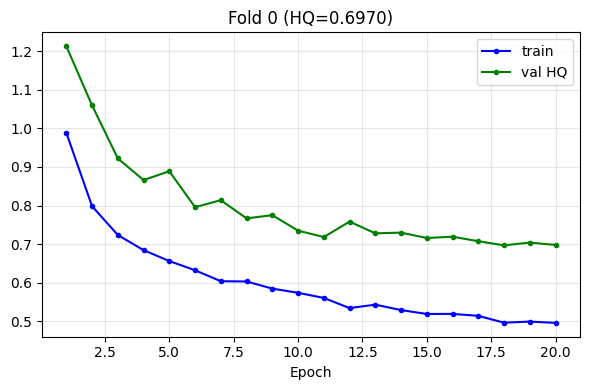

In [ ]:

n = len(all_histories)
fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
if n == 1: axes = [axes]
for ax, (fold, h) in zip(axes, all_histories.items()):
    ep = range(1, len(h["train_loss"])+1)
    ax.plot(ep, h["train_loss"], "b-o", ms=3, label="train")
    ax.plot(ep, h["val_loss_hq"], "g-o", ms=3, label="val HQ")
    ax.set_title(f"Fold {fold} (HQ={fold_results[fold]['hq']:.4f})")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

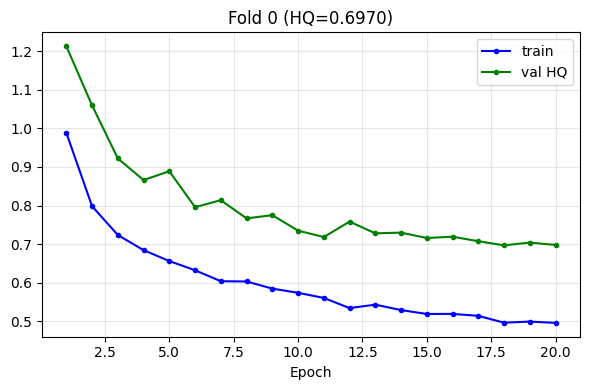

In [ ]:

n = len(all_histories)
fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
if n == 1: axes = [axes]
for ax, (fold, h) in zip(axes, all_histories.items()):
    ep = range(1, len(h["train_loss"])+1)
    ax.plot(ep, h["train_loss"], "b-o", ms=3, label="train")
    ax.plot(ep, h["val_loss_hq"], "g-o", ms=3, label="val HQ")
    ax.set_title(f"Fold {fold} (HQ={fold_results[fold]['hq']:.4f})")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Inference

In [ ]:
# Preprocess test EEGs
unique_test = test_df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
print(f"Processing {len(unique_test)} test EEGs...")
_ = joblib.Parallel(n_jobs=-1, backend="loky")(
    joblib.delayed(preprocess_eeg)(i, unique_test, "test")
    for i in tqdm(range(len(unique_test)))
)
print("Done test preprocessing")




test_ds = HMSDataset(test_df, mode="test")
test_loader = DataLoader(test_ds, batch_size=min(CFG.batch_size, len(test_df)),
                          shuffle=False, num_workers=CFG.num_workers, pin_memory=True)

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds = []
    for eeg, stats in tqdm(loader, desc="Predicting"):
        with autocast(enabled=CFG.use_amp):
            p = model(eeg.to(device), stats.to(device))
        preds.append(p.cpu().numpy())
    return np.concatenate(preds, axis=0)

all_preds = []
for fold in CFG.run_folds:
    ckpt_path = MODELS_DIR / f"best_model_fold{fold}.pt"
    if not ckpt_path.exists():
        continue
    model = SpectrogramModel(CFG).to(CFG.device)
    model.load_state_dict(torch.load(str(ckpt_path), map_location=CFG.device)["model_state_dict"])
    all_preds.append(predict(model, test_loader, CFG.device))
    print(f"Fold {fold}: done")
    del model; gc.collect(); torch.cuda.empty_cache()

preds = np.mean(all_preds, axis=0)
preds = preds / preds.sum(axis=1, keepdims=True)  # normalize

# temperature = 0.5
# preds = preds ** (1 / temperature)
# preds = preds / preds.sum(axis=1, keepdims=True)


print(f"Ensemble: {len(all_preds)} folds, shape={preds.shape}, sum={preds[0].sum():.4f}")

Processing 1 test EEGs...


  0%|          | 0/1 [00:00<?, ?it/s]

Done test preprocessing


/opt/conda/envs/AL/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/envs/AL/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


AxisError: axis 1 is out of bounds for array of dimension 0

# Submission

In [ ]:
target_cols = [x.lower() + "_vote" for x in CFG.class_names]
pred_df = test_df[["eeg_id"]].copy()
pred_df[target_cols] = preds.tolist()

sub_df = pd.read_csv(BASE_PATH / "sample_submission.csv")[["eeg_id"]]
sub_df = sub_df.merge(pred_df, on="eeg_id", how="left")
sub_df.to_csv(str(RESULTS_DIR / "submission.csv"), index=False)
print(f"Saved: {len(sub_df)} rows")
print(sub_df.head())

Saved: 1 rows
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  3911565283      0.043847   0.00092  0.000145   0.077036   0.307261   

   other_vote  
0    0.570792  
